In [418]:
import os
import copy
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from cmocean import cm

In [419]:
import os
import glob
import copy

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from cmocean import cm

In [420]:
mesh_mask_file = (
    "/ocean/dtaneja/MOAD/analysis-dishika/grid/"
    "mesh_mask202108.nc"
)

original_file = (
    "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/"
    "hrdps_nemo_3h/HRDPS_NEMO_2008_precip_3h.nc"
)

recon_dir = (
    "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/results/"
    "daily_downscaled_2008_padded_january"
)

plot_output_dir = (
    "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/results/"
    "january_2008_atmospheric_plots"
)

os.makedirs(plot_output_dir, exist_ok=True)

In [421]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (
        ds_mesh["tmask"]
        .isel(t=0, z=0)
        .load()
        .values
        .astype(bool)
    )

    nemo_lat = ds_mesh["nav_lat"].load().values
    nemo_lon = ds_mesh["nav_lon"].load().values

nemo_y_size, nemo_x_size = water_mask.shape

print("NEMO grid shape:", water_mask.shape)
print("Number of water cells:", water_mask.sum())

NEMO grid shape: (898, 398)
Number of water cells: 81383


In [422]:
water_mask_da = xr.DataArray(
    water_mask,
    dims=("y", "x"),
    coords={
        "y": np.arange(nemo_y_size),
        "x": np.arange(nemo_x_size),
    },
    name="water_mask",
)

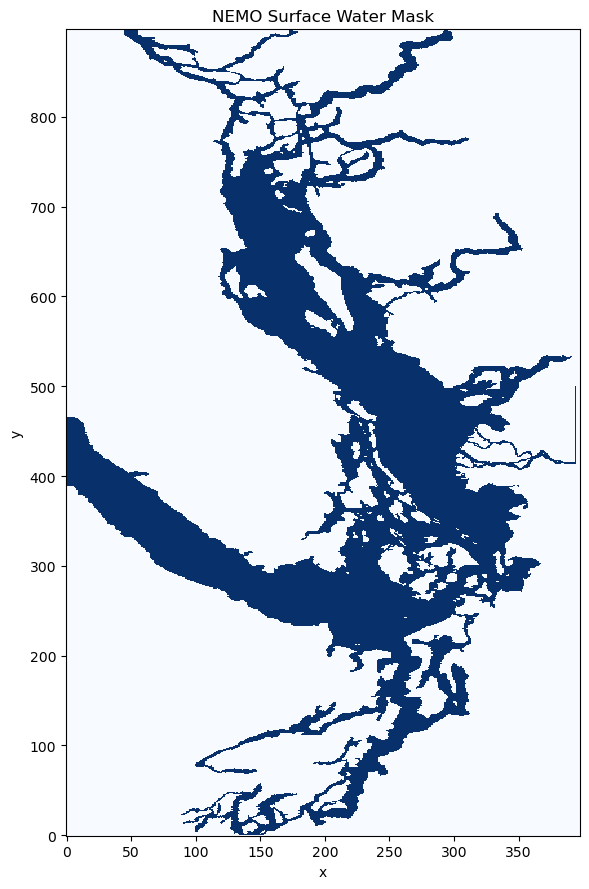

In [423]:
plt.figure(figsize=(6, 9))

water_mask_da.plot(
    cmap="Blues",
    add_colorbar=False
)

plt.title("NEMO Surface Water Mask")
plt.tight_layout()
plt.show()

In [424]:
if not os.path.exists(original_file):
    raise FileNotFoundError(
        f"Original HRDPS file not found:\n{original_file}"
    )

ds_original_water = xr.open_dataset(original_file)

print(ds_original_water)

<xarray.Dataset> Size: 955MB
Dimensions:       (time_counter: 2928, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 23kB 2008-01-01 ... 2008-12-3...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB ...
    nemo_i        (water_cell) int32 326kB ...
    nav_lat       (water_cell) float32 326kB ...
    nav_lon       (water_cell) float32 326kB ...
Data variables:
    precip        (time_counter, water_cell) float32 953MB ...
Attributes:
    description:  Raw hourly HRDPS precip interpolated onto NEMO surface wate...


In [425]:
january_mask = (
    (ds_original_water["time_counter"].dt.year == 2008)
    & (ds_original_water["time_counter"].dt.month == 1)
)

ds_original_january_water = (
    ds_original_water
    .sel(time_counter=january_mask)
    .sortby("time_counter")
    .load()
)

print("Original January dataset:")
print(ds_original_january_water)

print(
    "Original number of timestamps:",
    ds_original_january_water.sizes["time_counter"]
)

print(
    "Original time range:",
    ds_original_january_water.time_counter.values[0],
    "to",
    ds_original_january_water.time_counter.values[-1]
)

Original January dataset:
<xarray.Dataset> Size: 82MB
Dimensions:       (time_counter: 248, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2kB 2008-01-01 ... 2008-01-31...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB 1 1 1 1 1 1 ... 896 896 896 896 896
    nemo_i        (water_cell) int32 326kB 134 135 136 137 ... 175 293 294 295
    nav_lat       (water_cell) float32 326kB 47.11 47.12 47.12 ... 50.93 50.93
    nav_lon       (water_cell) float32 326kB -122.7 -122.7 ... -124.8 -124.8
Data variables:
    precip        (time_counter, water_cell) float32 81MB 0.0 0.0 ... 0.0 0.0
Attributes:
    description:  Raw hourly HRDPS precip interpolated onto NEMO surface wate...
Original number of timestamps: 248
Original time range: 2008-01-01T00:00:00.000000000 to 2008-01-31T21:00:00.000000000


In [426]:
if "nemo_j" not in ds_original_january_water.coords:
    raise KeyError(
        "The original dataset does not contain the nemo_j coordinate."
    )

if "nemo_i" not in ds_original_january_water.coords:
    raise KeyError(
        "The original dataset does not contain the nemo_i coordinate."
    )

nemo_j_indices = (
    ds_original_january_water["nemo_j"]
    .values
    .astype(np.int64)
)

nemo_i_indices = (
    ds_original_january_water["nemo_i"]
    .values
    .astype(np.int64)
)

n_original_times = (
    ds_original_january_water.sizes["time_counter"]
)

In [427]:
original_precip_full = np.full(
    (
        n_original_times,
        nemo_y_size,
        nemo_x_size,
    ),
    np.nan,
    dtype=np.float32,
)

In [428]:

original_precip_full[
    :,
    nemo_j_indices,
    nemo_i_indices,
] = ds_original_january_water["precip"].values

In [429]:
atmos_3h = xr.Dataset(
    data_vars={
        "precip": (
            ("time_counter", "y", "x"),
            original_precip_full,
        )
    },
    coords={
        "time_counter": (
            ds_original_january_water[
                "time_counter"
            ].values
        ),
        "y": np.arange(nemo_y_size),
        "x": np.arange(nemo_x_size),
        "nav_lat": (
            ("y", "x"),
            nemo_lat,
        ),
        "nav_lon": (
            ("y", "x"),
            nemo_lon,
        ),
    },
)

atmos_3h["precip"].attrs = (
    ds_original_january_water["precip"].attrs.copy()
)

atmos_3h["precip"].attrs["long_name"] = (
    atmos_3h["precip"].attrs.get(
        "long_name",
        "Precipitation",
    )
)

atmos_3h.attrs["description"] = (
    "Original HRDPS/GEMLAM Precipitation interpolated "
    "onto the NEMO grid and resampled to 3-hourly means."
)

In [430]:
atmos_3h["precip"] = atmos_3h["precip"].where(
    water_mask_da
)

In [431]:
print("atmos_3h:")
print(atmos_3h)

print(
    "atmos_3h precip shape:",
    atmos_3h["precip"].shape
)

atmos_3h:
<xarray.Dataset> Size: 357MB
Dimensions:       (time_counter: 248, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2kB 2008-01-01 ... 2008-01-31...
  * y             (y) int64 7kB 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
    nav_lat       (y, x) float32 1MB 46.86 46.86 46.86 46.87 ... 51.1 51.1 51.1
    nav_lon       (y, x) float32 1MB -123.4 -123.4 -123.4 ... -124.3 -124.3
Data variables:
    precip        (time_counter, y, x) float32 355MB nan nan nan ... nan nan nan
Attributes:
    description:  Original HRDPS/GEMLAM Precipitation interpolated onto the N...
atmos_3h precip shape: (248, 898, 398)


In [432]:
recon_files = sorted(
    glob.glob(
        os.path.join(
            recon_dir,
            "*y2008m01d*.nc",
        )
    )
)

if len(recon_files) == 0:
    raise FileNotFoundError(
        "No January 2008 reconstructed files were found in:\n"
        f"{recon_dir}"
    )

print(
    "Number of reconstructed files:",
    len(recon_files)
)

print("First file:", recon_files[0])
print("Last file: ", recon_files[-1])

Number of reconstructed files: 31
First file: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/results/daily_downscaled_2008_padded_january/downscaled_y2008m01d01.nc
Last file:  /ocean/dtaneja/MOAD/analysis-dishika/notebooks/results/daily_downscaled_2008_padded_january/downscaled_y2008m01d31.nc


In [433]:
try:
    atmos_recon_padded = xr.open_mfdataset(
        recon_files,
        combine="by_coords",
    )

except ValueError:
    print(
        "combine='by_coords' failed. "
        "Using nested concatenation."
    )

    atmos_recon_padded = xr.open_mfdataset(
        recon_files,
        combine="nested",
        concat_dim="time_counter",
    )

/tmp/ipykernel_2462099/2512620420.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  atmos_recon_padded = xr.open_mfdataset(


In [434]:
if "time_counter" not in atmos_recon_padded.dims:
    possible_time_dims = [
        dim
        for dim in atmos_recon_padded.dims
        if "time" in dim.lower()
    ]

    if len(possible_time_dims) != 1:
        raise ValueError(
            "Could not uniquely identify the time dimension. "
            f"Dataset dimensions are: {atmos_recon_padded.dims}"
        )

    atmos_recon_padded = atmos_recon_padded.rename(
        {
            possible_time_dims[0]: "time_counter"
        }
    )

In [435]:
atmos_recon_padded = atmos_recon_padded.sortby(
    "time_counter"
)

recon_time_index = pd.Index(
    pd.to_datetime(
        atmos_recon_padded[
            "time_counter"
        ].values
    )
)

if recon_time_index.has_duplicates:
    keep_times = ~recon_time_index.duplicated()

    atmos_recon_padded = (
        atmos_recon_padded.isel(
            time_counter=keep_times
        )
    )

In [436]:
recon_january_mask = (
    (
        atmos_recon_padded[
            "time_counter"
        ].dt.year
        == 2008
    )
    & (
        atmos_recon_padded[
            "time_counter"
        ].dt.month
        == 1
    )
)

atmos_recon_padded = (
    atmos_recon_padded
    .sel(time_counter=recon_january_mask)
    .sortby("time_counter")
)

In [437]:
print("Padded reconstructed dataset:")
print(atmos_recon_padded)

print(
    "Variables:",
    list(atmos_recon_padded.data_vars)
)

print(
    "Number of reconstructed timestamps:",
    atmos_recon_padded.sizes["time_counter"]
)

Padded reconstructed dataset:
<xarray.Dataset> Size: 4GB
Dimensions:       (time_counter: 248, y: 918, x: 418)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2kB 2008-01-01 ... 2008-01-31...
  * y             (y) int64 7kB 0 1 2 3 4 5 6 7 ... 911 912 913 914 915 916 917
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 411 412 413 414 415 416 417
Data variables:
    qair          (time_counter, y, x) float32 381MB dask.array<chunksize=(1, 918, 418), meta=np.ndarray>
    therm_rad     (time_counter, y, x) float32 381MB dask.array<chunksize=(1, 918, 418), meta=np.ndarray>
    precip        (time_counter, y, x) float32 381MB dask.array<chunksize=(1, 918, 418), meta=np.ndarray>
    atmpres       (time_counter, y, x) float32 381MB dask.array<chunksize=(1, 918, 418), meta=np.ndarray>
    solar         (time_counter, y, x) float32 381MB dask.array<chunksize=(1, 918, 418), meta=np.ndarray>
    tair          (time_counter, y, x) float32 381MB dask.array<chunksize=(1, 918, 418), 

In [438]:
if "precip" not in atmos_recon_padded:
    raise KeyError(
        "The reconstructed dataset does not contain 'precip'. "
        f"Available variables are: "
        f"{list(atmos_recon_padded.data_vars)}"
    )

In [439]:
recon_spatial_dims = [
    dim
    for dim in atmos_recon_padded["precip"].dims
    if dim != "time_counter"
]

if len(recon_spatial_dims) != 2:
    raise ValueError(
        "Expected two spatial dimensions for reconstructed precip, "
        f"but found: {recon_spatial_dims}"
    )

recon_y_dim, recon_x_dim = recon_spatial_dims

print("Reconstructed y dimension:", recon_y_dim)
print("Reconstructed x dimension:", recon_x_dim)

print(
    "Padded reconstructed shape:",
    atmos_recon_padded.sizes[recon_y_dim],
    atmos_recon_padded.sizes[recon_x_dim],
)

Reconstructed y dimension: y
Reconstructed x dimension: x
Padded reconstructed shape: 918 418


In [440]:
recon_y_size = atmos_recon_padded.sizes[
    recon_y_dim
]

recon_x_size = atmos_recon_padded.sizes[
    recon_x_dim
]

extra_y = recon_y_size - nemo_y_size
extra_x = recon_x_size - nemo_x_size

if extra_y < 0 or extra_x < 0:
    raise ValueError(
        "The reconstructed grid is smaller than the original "
        "NEMO grid."
    )

if extra_y % 2 != 0 or extra_x % 2 != 0:
    raise ValueError(
        "The padding is not symmetric. "
        f"Extra y cells: {extra_y}; "
        f"extra x cells: {extra_x}"
    )

pad_y = extra_y // 2
pad_x = extra_x // 2

print("Padding on each y side:", pad_y)

print("Padding on each x side:", pad_x)

Padding on each y side: 10
Padding on each x side: 10


In [441]:
atmos_recon = atmos_recon_padded.isel(
    {
        recon_y_dim: slice(
            pad_y,
            pad_y + nemo_y_size,
        ),
        recon_x_dim: slice(
            pad_x,
            pad_x + nemo_x_size,
        ),
    }
)

In [442]:
rename_dimensions = {}

if recon_y_dim != "y":
    rename_dimensions[recon_y_dim] = "y"

if recon_x_dim != "x":
    rename_dimensions[recon_x_dim] = "x"

if rename_dimensions:
    atmos_recon = atmos_recon.rename(
        rename_dimensions
    )

In [443]:
atmos_recon = atmos_recon.assign_coords(
    y=np.arange(nemo_y_size),
    x=np.arange(nemo_x_size),
    nav_lat=(
        ("y", "x"),
        nemo_lat,
    ),
    nav_lon=(
        ("y", "x"),
        nemo_lon,
    ),
)

In [444]:
atmos_recon = atmos_recon.where(
    water_mask_da
)

In [445]:
print("atmos_recon:")
print(atmos_recon)

print(
    "Cropped reconstructed precip shape:",
    atmos_recon["precip"].shape
)

atmos_recon:
<xarray.Dataset> Size: 3GB
Dimensions:       (time_counter: 248, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2kB 2008-01-01 ... 2008-01-31...
  * y             (y) int64 7kB 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
    nav_lat       (y, x) float32 1MB 46.86 46.86 46.86 46.87 ... 51.1 51.1 51.1
    nav_lon       (y, x) float32 1MB -123.4 -123.4 -123.4 ... -124.3 -124.3
Data variables:
    qair          (time_counter, y, x) float32 355MB dask.array<chunksize=(1, 898, 398), meta=np.ndarray>
    therm_rad     (time_counter, y, x) float32 355MB dask.array<chunksize=(1, 898, 398), meta=np.ndarray>
    precip        (time_counter, y, x) float32 355MB dask.array<chunksize=(1, 898, 398), meta=np.ndarray>
    atmpres       (time_counter, y, x) float32 355MB dask.array<chunksize=(1, 898, 398), meta=np.ndarray>
    solar         (time_counter, y, x) float32 355MB das

In [446]:
# Original HRDPS/GEMLAM on the NEMO grid
print(atmos_3h)

# Padded downscaled files
print(atmos_recon_padded)

# Downscaled files cropped to the original NEMO grid
print(atmos_recon)

<xarray.Dataset> Size: 357MB
Dimensions:       (time_counter: 248, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2kB 2008-01-01 ... 2008-01-31...
  * y             (y) int64 7kB 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
    nav_lat       (y, x) float32 1MB 46.86 46.86 46.86 46.87 ... 51.1 51.1 51.1
    nav_lon       (y, x) float32 1MB -123.4 -123.4 -123.4 ... -124.3 -124.3
Data variables:
    precip        (time_counter, y, x) float32 355MB nan nan nan ... nan nan nan
Attributes:
    description:  Original HRDPS/GEMLAM Precipitation interpolated onto the N...
<xarray.Dataset> Size: 4GB
Dimensions:       (time_counter: 248, y: 918, x: 418)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2kB 2008-01-01 ... 2008-01-31...
  * y             (y) int64 7kB 0 1 2 3 4 5 6 7 ... 911 912 913 914 915 916 917
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 411 412 41

In [447]:
print(
    "Original timestamps:",
    atmos_3h.sizes["time_counter"]
)

print(
    "Reconstructed timestamps:",
    atmos_recon.sizes["time_counter"]
)

print(
    "Original range:",
    atmos_3h.time_counter.values[0],
    "to",
    atmos_3h.time_counter.values[-1]
)

print(
    "Reconstructed range:",
    atmos_recon.time_counter.values[0],
    "to",
    atmos_recon.time_counter.values[-1]
)

Original timestamps: 248
Reconstructed timestamps: 248
Original range: 2008-01-01T00:00:00.000000000 to 2008-01-31T21:00:00.000000000
Reconstructed range: 2008-01-01T00:00:00.000000000 to 2008-01-31T21:00:00.000000000


In [448]:
original_times = pd.to_datetime(
    atmos_3h["time_counter"].values
)

reconstructed_times = pd.to_datetime(
    atmos_recon["time_counter"].values
)

common_times = np.intersect1d(
    original_times.values,
    reconstructed_times.values,
)

if len(common_times) == 0:
    raise ValueError(
        "No matching timestamps were found between the "
        "original and reconstructed datasets."
    )

atmos_3h = atmos_3h.sel(
    time_counter=common_times
)

atmos_recon = atmos_recon.sel(
    time_counter=common_times
)

print(
    "Number of matching timestamps:",
    len(common_times)
)

print(
    "Aligned original shape:",
    atmos_3h["precip"].shape
)

print(
    "Aligned reconstruction shape:",
    atmos_recon["precip"].shape
)

Number of matching timestamps: 248
Aligned original shape: (248, 898, 398)
Aligned reconstruction shape: (248, 898, 398)


In [449]:
def triple_plot_mean(
    original,
    reconstructed,
    var,
    cmap,
    vmin=None,
    vmax=None,
    dv=None,
):
    original_mean = original[var].mean(
        dim="time_counter",
        skipna=True,
    )

    reconstructed_mean = reconstructed[var].mean(
        dim="time_counter",
        skipna=True,
    )

    difference_mean = (
        reconstructed_mean
        - original_mean
    )

    # Determine a shared scale for the first two panels
    if vmin is None or vmax is None:
        combined_values = np.concatenate(
            [
                original_mean.values.ravel(),
                reconstructed_mean.values.ravel(),
            ]
        )

        combined_values = combined_values[
            np.isfinite(combined_values)
        ]

        vmin, vmax = np.nanpercentile(
            combined_values,
            [1, 99],
        )

    # Determine a symmetric difference scale
    if dv is None:
        valid_difference = difference_mean.values[
            np.isfinite(difference_mean.values)
        ]

        dv = np.nanpercentile(
            np.abs(valid_difference),
            99,
        )

        if dv == 0:
            dv = 1

    main_cmap = copy.copy(cmap)
    main_cmap = main_cmap.with_extremes(
        bad="burlywood"
    )

    difference_cmap = copy.copy(cm.balance)
    difference_cmap = (
        difference_cmap.with_extremes(
            bad="burlywood"
        )
    )

    fig, axs = plt.subplots(
        1,
        3,
        figsize=(15, 9),
        constrained_layout=True,
    )

    original_mean.plot(
        ax=axs[0],
        cmap=main_cmap,
        vmin=vmin,
        vmax=vmax,
    )

    reconstructed_mean.plot(
        ax=axs[1],
        cmap=main_cmap,
        vmin=vmin,
        vmax=vmax,
    )

    difference_mean.plot(
        ax=axs[2],
        cmap=difference_cmap,
        vmin=-dv,
        vmax=dv,
    )

    axs[0].set_title(
        "Original HRDPS/GEMLAM\n3-hourly mean"
    )

    axs[1].set_title(
        "Downscaled reconstruction\n3-hourly mean"
    )

    axs[2].set_title(
        "Reconstruction − Original"
    )

    grid_aspect = original_mean.sizes["y"] / original_mean.sizes["x"]

    for ax in axs:
        ax.set_box_aspect(grid_aspect)
        ax.set_xlabel("NEMO x index")
        ax.set_ylabel("NEMO y index")

    return fig, axs

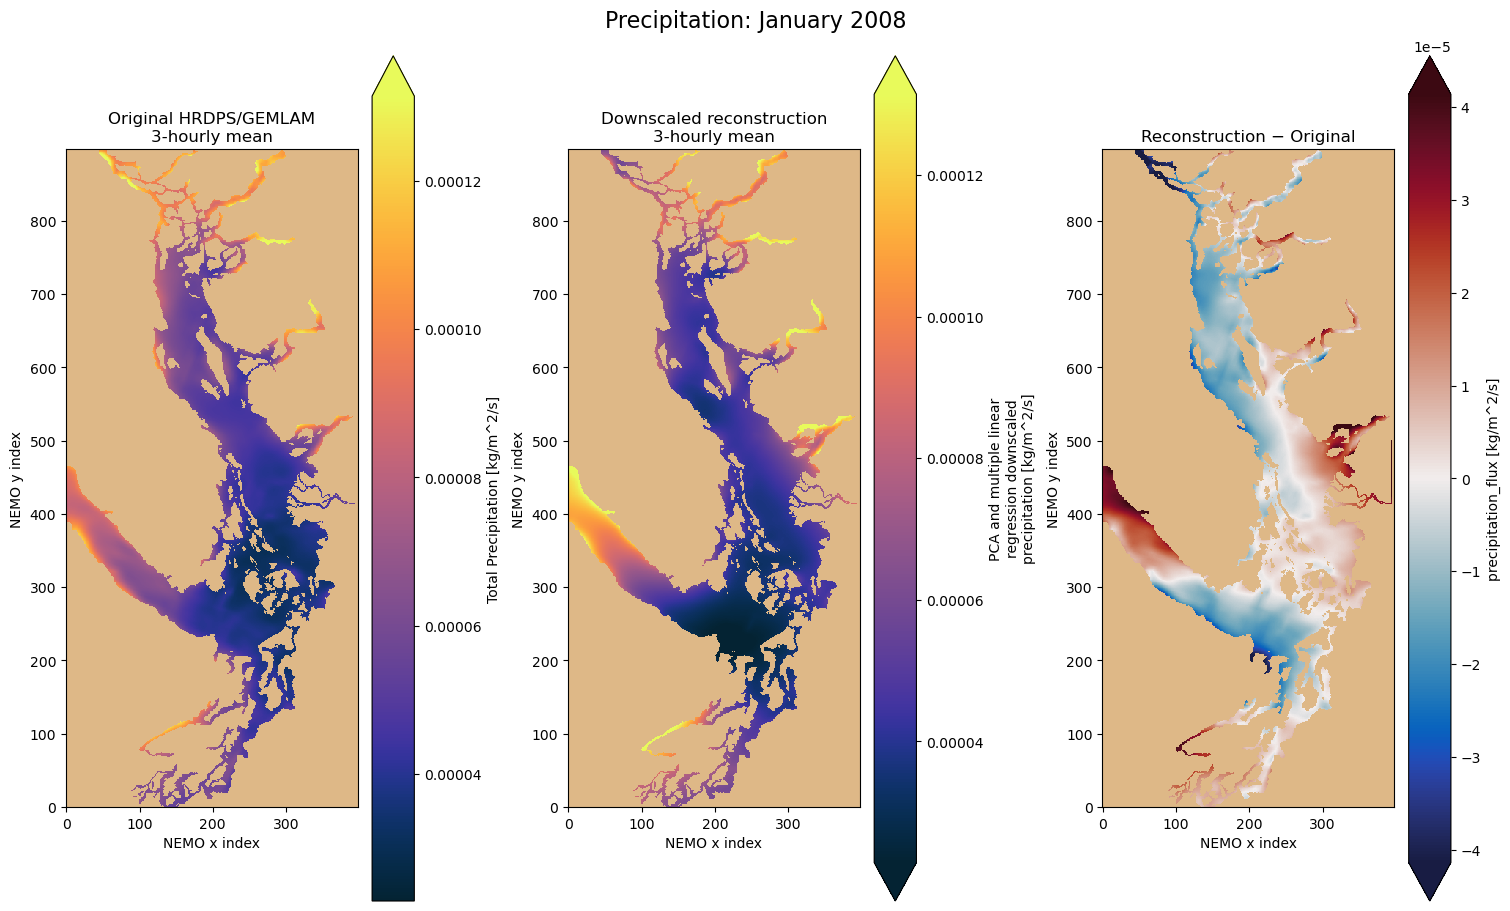

In [450]:
fig, axs = triple_plot_mean(
    original=atmos_3h,
    reconstructed=atmos_recon,
    var="precip",
    cmap=cm.thermal,
)

fig.suptitle(
    "Precipitation: January 2008",
    fontsize=16,
)

plt.show()

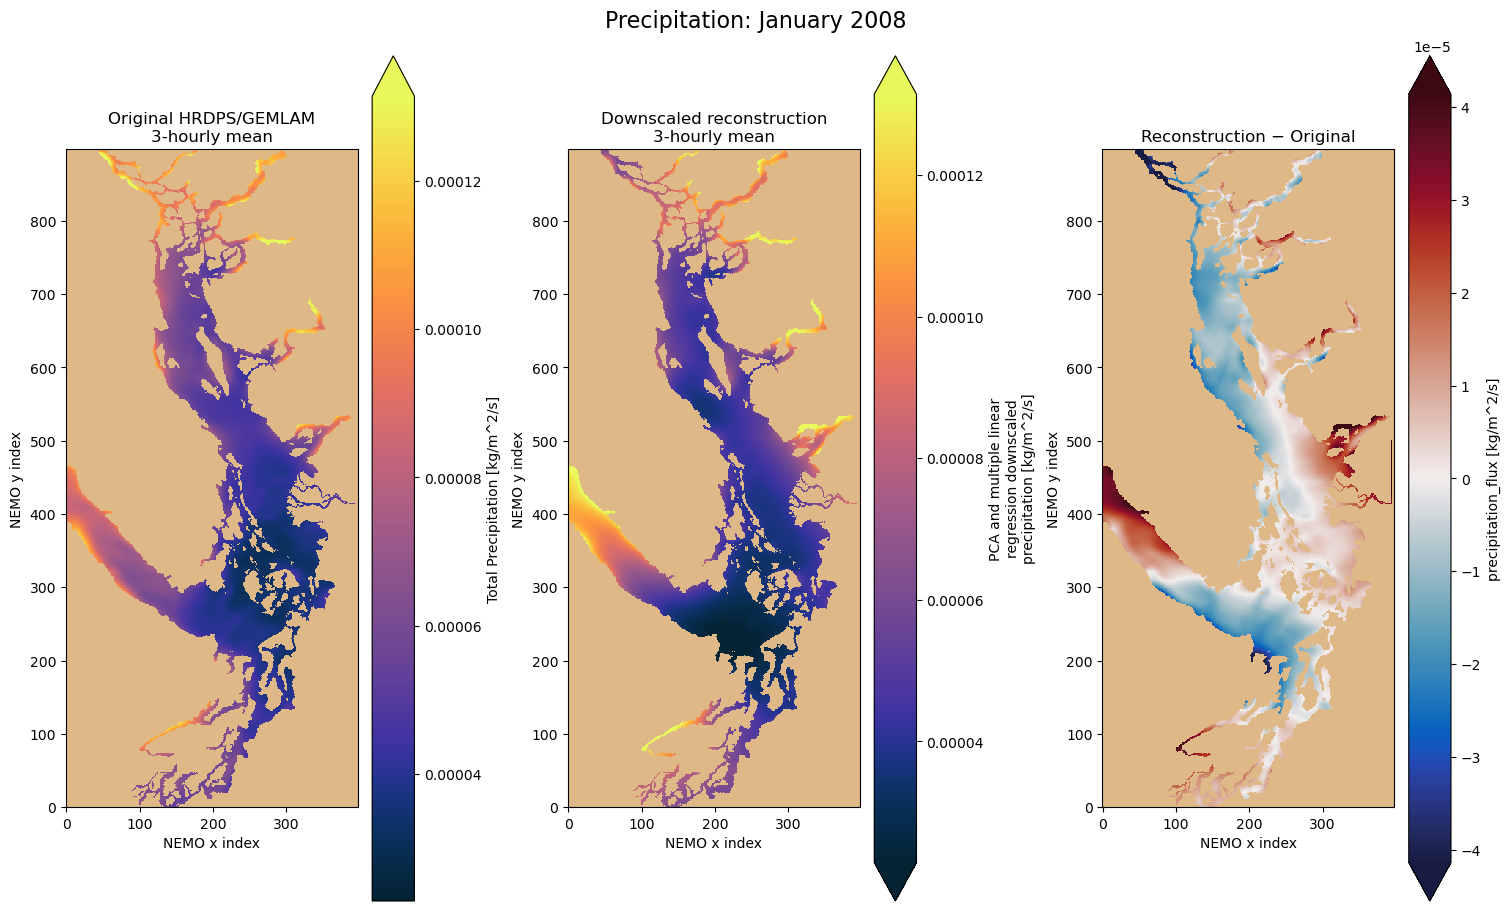

Saved: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/results/january_2008_atmospheric_plots/precip_mean_comparison_january_2008.png


In [451]:
fig, axs = triple_plot_mean(
    original=atmos_3h,
    reconstructed=atmos_recon,
    var="precip",
    cmap=cm.thermal,
)

fig.suptitle(
    "Precipitation: January 2008",
    fontsize=16,
)

output_plot = os.path.join(
    plot_output_dir,
    "precip_mean_comparison_january_2008.png",
)

fig.savefig(
    output_plot,
    dpi=250,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("Saved:", output_plot)